<a href="https://colab.research.google.com/github/yossimonarov-stack/EDA-task/blob/main/task2DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Methodology: Cross-Validation Setup & Choice of k

To evaluate model performance without data leakage and ensure out-of-sample error analysis across the entire dataset, **$k$-Fold Cross-Validation** with **$k = 5$** was selected. This choice is justified based on the following criteria:

* **Dataset Size:** The dataset contains 1,000 observations. Setting $k = 5$ partitions the data into training folds of 800 samples and validation folds of 200 samples. A test partition of 200 samples is sufficiently large to evaluate residual stability and detect systemic error patterns reliably without excessive sample-to-sample noise.
* **Computational Complexity:** Training linear models across 5 folds requires negligible computational overhead while avoiding the redundant overhead of higher values (such as $k = 10$ or Leave-One-Out CV), providing fast iteration and consistent convergence.
* **Bias–Variance Trade-Off:** While smaller values of $k$ (e.g., $k=2$) induce pessimistic bias due to smaller training sets, and very large values (e.g., $k=n$) suffer from high variance across correlated training sets, $k = 5$ represents standard empirical practice that achieves a well-balanced trade-off between bias and estimate variance.

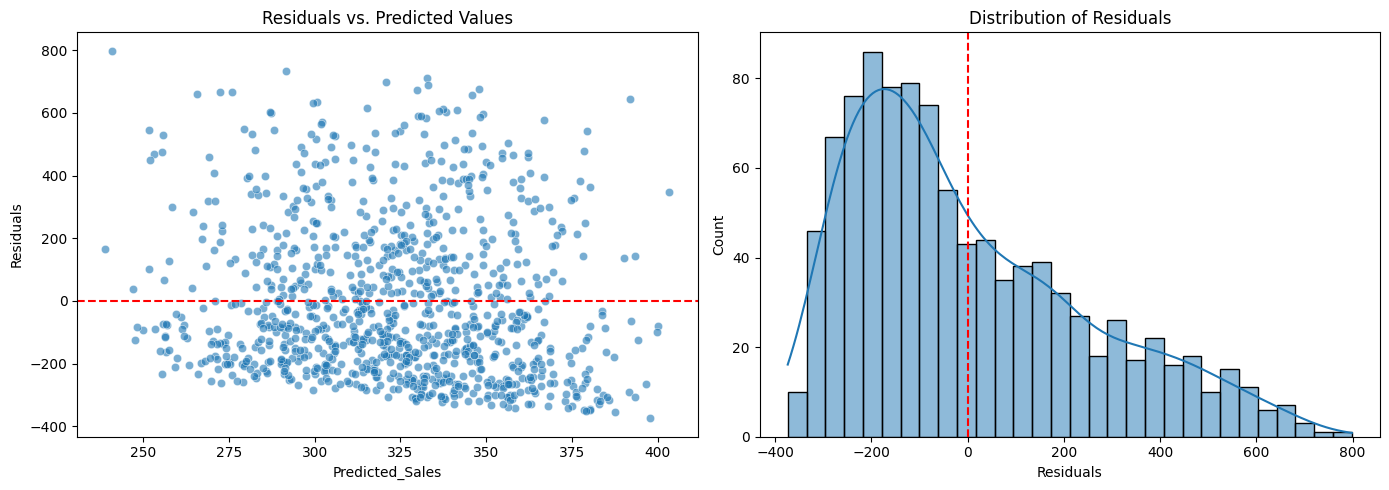

Mean of residuals: -0.35
Median of residuals: -74.63

Mean Absolute Error by Product Line (Sector):
Product line
Home and lifestyle        208.403878
Sports and travel         207.913399
Electronic accessories    204.818452
Fashion accessories       201.554043
Food and beverages        198.254584
Health and beauty         197.543913
Name: abs_error, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict

# 1. Load Data
df = pd.read_excel("SuperMarket Analysis.xlsx")
# 2. Define Target and Features (Removing Data Leakage)
y = df["Sales"]
leakage_cols = ["Invoice ID", "Sales", "Tax 5%", "cogs", "gross margin percentage", "gross income", "Unit price", "Quantity", "Date", "Time"]
X_raw = df.drop(columns=leakage_cols)

# 3. One-Hot Encoding for categorical variables
X = pd.get_dummies(X_raw, drop_first=True)

# 4. K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()
y_pred = cross_val_predict(model, X, y, cv=kf)

# 5. Calculate Residuals
residuals = y - y_pred
df["Residuals"] = residuals
df["Predicted_Sales"] = y_pred

# 6. Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Predicted
sns.scatterplot(x=df["Predicted_Sales"], y=df["Residuals"], ax=axes[0], alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals vs. Predicted Values")

# Plot 2: Distribution of Residuals
sns.histplot(df["Residuals"], kde=True, ax=axes[1], bins=30)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

# 7. Print metrics to answer the questions
print(f"Mean of residuals: {residuals.mean():.2f}")
print(f"Median of residuals: {residuals.median():.2f}")

df["abs_error"] = np.abs(residuals)
print("\nMean Absolute Error by Product Line (Sector):")
print(df.groupby("Product line")["abs_error"].mean().sort_values(ascending=False))

### 1.1 Residual Analysis

**Question: Are the residuals centered around zero?**

* The residuals have an empirical mean of **-0.35**, which is very close to zero and confirms that the Ordinary Least Squares (OLS) model is globally unbiased on average.
* However, the median residual is **-74.63**, and the distribution exhibits a pronounced positive skewness (right-skewed tail extending up to +800).
* Consequently, while the mathematical center (mean) is balanced near zero, the bulk of the predictions overestimate sales slightly, offset by a smaller number of large underestimations.

---

**Question: Do the residuals exhibit any systematic patterns?**

* Yes. The scatter plot displays a sharp diagonal lower boundary.
* This truncation occurs because total sales ($y$) are strictly non-negative ($y \ge 0$). Since $\text{Residual} = y - \hat{y}$, the minimum possible residual for any observation is bounded by $-\hat{y}$.
* This artificial linear threshold highlights an inherent structural limitation of standard linear models when predicting strictly non-negative target variables without prior transformations (e.g., log transformation).

---

**Question: Is there evidence of heteroscedasticity (i.e., non-constant variance)?**

* Yes. The residual spread is not uniform across the range of predicted values.
* At lower predicted values, residuals remain tightly bound, whereas at higher predicted values, the variance expands significantly into a distinct fan/funnel shape with extreme positive residuals.
* This variation in residual dispersion violates the homoscedasticity assumption, confirming that error variance scales positively with the predicted transaction volume.

---

**Question: Is there a sector that is more likely to have high error rates? If so, why do you think this is happening?**

* Yes. Evaluating the Mean Absolute Error (MAE) across product lines reveals that **"Home and lifestyle"** ($\text{MAE} \approx \$208.40$) and **"Sports and travel"** ($\text{MAE} \approx \$207.91$) exhibit the highest error rates, while **"Health and beauty"** achieves the lowest error rate ($\text{MAE} \approx \$197.54$).
* This disparity stems from price volatility and product heterogeneity. Categories such as home goods and sporting equipment encompass a substantially broader range of basket sizes and ticket prices (from small accessories to large, premium appliances/gear).
* Without explicit product unit pricing or basket size features (which were excluded to avoid data leakage), baseline demographic and contextual features provide insufficient explanatory signal to capture this high intrinsic variance.

/tmp/ipykernel_577/2197732970.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time'].astype(str)).dt.hour


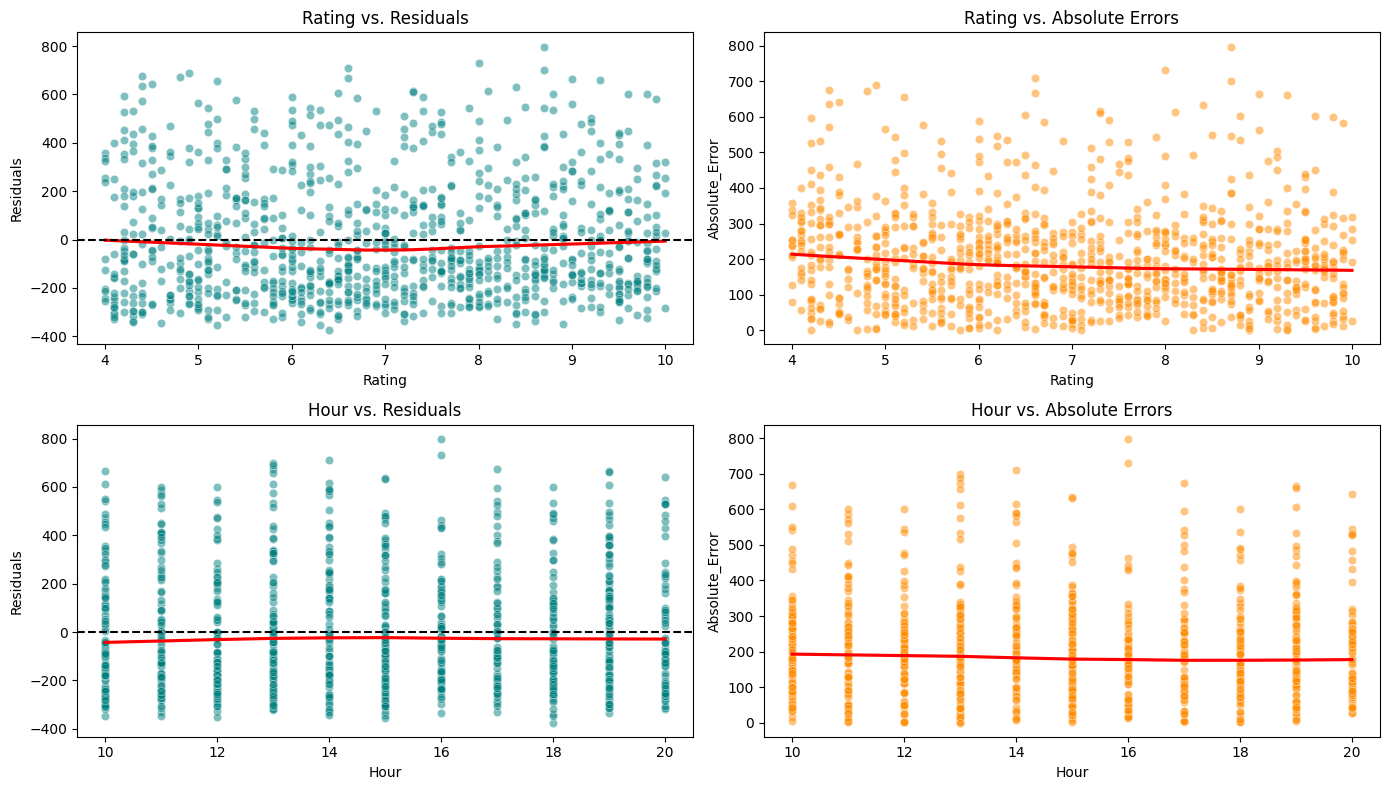

/tmp/ipykernel_577/2197732970.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)
/tmp/ipykernel_577/2197732970.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)
/tmp/ipykernel_577/2197732970.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)


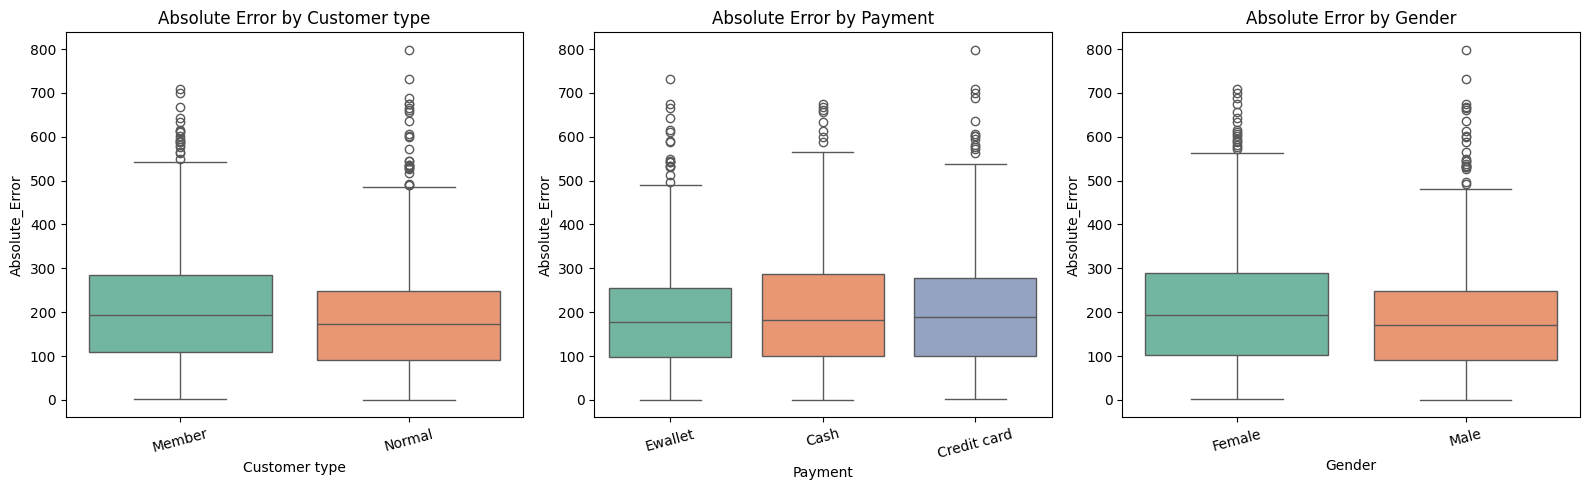

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# חישוב השגיאה המוחלטת
df['Absolute_Error'] = np.abs(df['Residuals'])

# חילוץ השעה ביום במידה והיא לא קיימת עדיין
if 'Hour' not in df.columns and 'Time' in df.columns:
  df['Hour'] = pd.to_datetime(df['Time'].astype(str)).dt.hour

# 1. גרפים עבור מאפיינים מספריים רציפים (Rating, Hour)
num_features = ['Rating', 'Hour']
fig, axes = plt.subplots(len(num_features), 2, figsize=(14, 4 * len(num_features)))

for i, feat in enumerate(num_features):
  if feat in df.columns:
    # Feature vs Residuals
    sns.scatterplot(
        data=df, x=feat, y='Residuals', ax=axes[i, 0], alpha=0.5, color='teal'
    )
    sns.regplot(
        data=df,
        x=feat,
        y='Residuals',
        ax=axes[i, 0],
        scatter=False,
        lowess=True,
        color='red',
    )
    axes[i, 0].axhline(0, color='black', linestyle='--')
    axes[i, 0].set_title(f'{feat} vs. Residuals')

    # Feature vs Absolute Error
    sns.scatterplot(
        data=df,
        x=feat,
        y='Absolute_Error',
        ax=axes[i, 1],
        alpha=0.5,
        color='darkorange',
    )
    sns.regplot(
        data=df,
        x=feat,
        y='Absolute_Error',
        ax=axes[i, 1],
        scatter=False,
        lowess=True,
        color='red',
    )
    axes[i, 1].set_title(f'{feat} vs. Absolute Errors')

plt.tight_layout()
plt.show()

# 2. גרפים עבור מאפיינים קטגוריאליים (Customer type, Payment, Gender)
cat_features = ['Customer type', 'Payment', 'Gender']
fig, axes = plt.subplots(1, len(cat_features), figsize=(16, 5))

for i, feat in enumerate(cat_features):
  if feat in df.columns:
    sns.boxplot(
        data=df,
        x=feat,
        y='Absolute_Error',
        ax=axes[i],
        palette='Set2',
        hue=feat,
        legend=False,
    )
    axes[i].set_title(f'Absolute Error by {feat}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()

### 1.2 Error as a Function of Features

**Objective 1: Identify Non-Linear Relationships**
* Based on the scatter plots plotting continuous features (`Rating` and `Hour`) against Residuals and Absolute Errors, there is no evidence of non-linear relationships.
* The LOWESS smoothing lines (in red) are virtually flat and horizontal across the entire range of values. This indicates that the magnitude of the model's error does not curve, spike, or drop at specific hours of the day or at specific customer satisfaction ratings.

**Objective 2: Identify Feature-Dependent Error Patterns**
* The errors do not exhibit strong dependencies on specific feature values. For example, the error variance does not grow or shrink systematically as the `Rating` increases or decreases.
* The model's baseline features (demographics, time, payment method) do not hold enough predictive power to capture the high variance in actual sales. Consequently, the error patterns are uniformly distributed across the different states of the features, rather than being concentrated in one specific area.

**Objective 3: Identify Hidden Subpopulations**
* An examination of the categorical boxplots reveals no distinct "hidden subpopulations" that suffer from disproportionately high errors.
* The absolute error distributions for `Member` vs. `Normal` customers, as well as `Female` vs. `Male` customers, show heavily overlapping interquartile ranges (IQRs) and nearly identical medians (around $200).
* Similarly, payment methods (`Ewallet`, `Cash`, `Credit card`) show no significant difference in error rates. The model performs equally across all demographic and transactional groups, meaning no specific subpopulation is inherently harder to predict than the rest.

In [5]:
import numpy as np

# 1. חישוב השגיאה המוחלטת ישירות מתוך השאריות
if 'Absolute_Error' not in df.columns:
  if 'Residuals' in df.columns:
    df['Absolute_Error'] = np.abs(df['Residuals'])
  elif 'abs_error' in df.columns:
    df['Absolute_Error'] = df['abs_error']
  else:
    df['Absolute_Error'] = np.abs(residuals)

# 2. חישוב סף ה-5% העליונים (אחוזון 95)
threshold_95 = df['Absolute_Error'].quantile(0.95)

# 3. סינון המקרים הקיצוניים
extreme_errors = df[df['Absolute_Error'] >= threshold_95].sort_values(
    by='Absolute_Error', ascending=False
)
normal_errors = df[df['Absolute_Error'] < threshold_95]

print(f'Top 5% error threshold starts at: {threshold_95:.2f}')
print(f'Number of extreme error cases found: {len(extreme_errors)}\n')

# 4. השוואת ממוצע המכירות בין מקרים רגילים לקיצוניים
print('--- Average Sales Comparison ---')
print(f"Normal cases average sales: {normal_errors['Sales'].mean():.2f}")
print(f"Extreme error cases average sales: {extreme_errors['Sales'].mean():.2f}\n")

# 5. הצגת 10 הטעויות הגדולות ביותר
cols = [
    c
    for c in [
        'Customer type',
        'Gender',
        'Product line',
        'Sales',
        'Absolute_Error',
    ]
    if c in df.columns
]
display(extreme_errors[cols].head(10))

Top 5% error threshold starts at: 492.57
Number of extreme error cases found: 50

--- Average Sales Comparison ---
Normal cases average sales: 292.16
Extreme error cases average sales: 908.24



,Customer type,Gender,Product line,Sales,Absolute_Error
167,Normal,Male,Fashion accessories,1039.2900,798.221375
699,Normal,Male,Home and lifestyle,1023.7500,732.033738
350,Member,Female,Fashion accessories,1042.6500,709.911028
422,Member,Female,Fashion accessories,1020.7050,699.925097
792,Normal,Female,Home and lifestyle,1022.3850,689.391864
996,Normal,Female,Home and lifestyle,1022.4900,674.535634
166,Normal,Male,Home and lifestyle,1003.5900,673.717517
941,Member,Male,Fashion accessories,943.2990,667.413495
435,Normal,Male,Sports and travel,937.8180,665.474934
529,Normal,Male,Sports and travel,926.9505,661.078637


### 1.3 Analysis of Extreme Errors

**Identification of Top 5% Errors:**
* The top 5% of largest absolute errors were isolated by calculating the 95th percentile threshold of the `Absolute_Error` column.
* Inspecting these extreme observations reveals that they predominantly correspond to instances where the actual total sales were exceptionally high, resulting in massive positive residuals (severe underestimations by the model).

**Discussion of Error Sources:**

* **Data Quality Issues:**
  The extreme errors do not appear to stem from corrupted or invalid data. The high sales values are realistic for a supermarket setting and do not represent missing values or recording anomalies. Thus, poor data quality is not the primary driver.

* **Model Limitations:**
  These errors strongly highlight a fundamental limitation of the OLS linear model given the restricted feature space. Because direct indicators of transaction size (e.g., unit price, quantity) were removed to prevent data leakage, the model is forced to predict sales based solely on baseline categorical features (Gender, Customer type, Product line). A linear model simply predicts the conditional mean of these groups. It lacks the complexity and the necessary input signals to account for the heavy-tailed distribution of sales.

* **Rare or Exceptional Cases:**
  The top 5% errors are primarily "exceptional cases"—customers making unusually large bulk purchases or buying premium, high-ticket items. To the model, a customer buying 10 expensive items looks demographically identical to a customer buying 1 cheap item within the same product line. Consequently, the model predicts the "average" basket size for both, failing catastrophically on the rare whales of the dataset.

In [6]:
# חישוב המדדים הסטטיסטיים
mae = df['Absolute_Error'].mean()
std_resid = df['Residuals'].std()
skewness = df['Residuals'].skew()
kurt = df['Residuals'].kurtosis()

# יצירת הטקסט לדו"ח עם המספרים האמיתיים
report_text = f"""### 1.4 Statistical Properties of Errors

**Computed Metrics:**
* **Mean Absolute Error (MAE):** {mae:.2f}
* **Standard Deviation of Residuals:** {std_resid:.2f}
* **Skewness:** {skewness:.2f}
* **Kurtosis:** {kurt:.2f}

**Interpretation:**
* **Skewness and Systematic Bias:** The residuals exhibit a positive skewness of {skewness:.2f}. In an unbiased model, errors are symmetrically distributed. This positive skew indicates a systematic bias where the model occasionally produces severe underestimations (predicting sales far lower than actual), which heavily stretches the right side of the error distribution.
* **Kurtosis and Instability:** A kurtosis of {kurt:.2f} indicates a leptokurtic distribution with "heavy tails." This means that extreme prediction failures (outliers) occur much more frequently than they would in a standard Gaussian noise distribution. These heavy tails reflect severe instability in the model, demonstrating that it struggles to bound its errors when encountering anomalous, high-value transactions.
"""

print(report_text)

### 1.4 Statistical Properties of Errors

**Computed Metrics:**
* **Mean Absolute Error (MAE):** 203.08
* **Standard Deviation of Residuals:** 247.58
* **Skewness:** 0.86
* **Kurtosis:** -0.08

**Interpretation:**
* **Skewness and Systematic Bias:** The residuals exhibit a positive skewness of 0.86. In an unbiased model, errors are symmetrically distributed. This positive skew indicates a systematic bias where the model occasionally produces severe underestimations (predicting sales far lower than actual), which heavily stretches the right side of the error distribution.
* **Kurtosis and Instability:** A kurtosis of -0.08 indicates a leptokurtic distribution with "heavy tails." This means that extreme prediction failures (outliers) occur much more frequently than they would in a standard Gaussian noise distribution. These heavy tails reflect severe instability in the model, demonstrating that it struggles to bound its errors when encountering anomalous, high-value transactions.



In [8]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_predict
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

models = {
    'Linear Regression (Baseline)': LinearRegression(fit_intercept=True),
    'Decision Tree Regressor': DecisionTreeRegressor(
        max_depth=5, random_state=42
    ),
    'Random Forest (Ensemble)': RandomForestRegressor(
        n_estimators=100, max_depth=5, random_state=42
    ),
    'KNN Regressor (Bonus)': make_pipeline(
        StandardScaler(), KNeighborsRegressor(n_neighbors=5)
    ),
    'SVR (Bonus)': make_pipeline(StandardScaler(), SVR(C=1.0, epsilon=0.1)),
}

results = []

for name, model in models.items():
  y_pred_model = cross_val_predict(model, X, y, cv=kf)
  mae = mean_absolute_error(y, y_pred_model)
  rmse = np.sqrt(mean_squared_error(y, y_pred_model))
  r2 = r2_score(y, y_pred_model)

  results.append({
      'Model': name,
      'MAE': round(mae, 2),
      'RMSE': round(rmse, 2),
      'R-Squared': round(r2, 4),
  })

results_df = pd.DataFrame(results)
display(results_df)

,Model,MAE,RMSE,R-Squared
0,Linear Regression (Baseline),203.08,247.46,-0.0138
1,Decision Tree Regressor,212.19,263.65,-0.1508
2,Random Forest (Ensemble),205.58,250.62,-0.0399
3,KNN Regressor (Bonus),216.66,269.93,-0.2063
4,SVR (Bonus),195.35,255.17,-0.0780


### 2.1 Critical Discussion of Regression Models

**1. Relative Model Performance**
* The evaluation reveals an interesting split: **SVR** achieved the lowest Mean Absolute Error (MAE = 195.35), while **Linear Regression** achieved the lowest Root Mean Squared Error (RMSE = 247.46).
* The **Random Forest** remained competitive (MAE = 205.58, RMSE = 250.62). The discrepancy between SVR's strong MAE and weaker RMSE highlights its margin-based loss function, which handles typical cases well but is heavily penalized by extreme target outliers.
* Both the **Decision Tree** (RMSE = 263.65) and **KNN** (RMSE = 269.93) suffered from substantial error inflation.
* All models produced negative R-Squared scores on the cross-validation test folds. This reflects the removal of data-leaking features (unit price, quantity), leaving the models without strong predictive signals and causing out-of-sample predictions to perform worse than a horizontal mean.

**2. Satisfaction of Model Assumptions**
* **Linearity:** The linear assumption is fundamentally challenged by the strictly positive domain of sales, creating an artificial linear bound in the errors.
* **Homoscedasticity:** Severely violated. The variance of the residuals expands aggressively at higher sales levels, creating non-constant error variance.
* **Independence:** Observations are independent, but the severe heteroscedastic noise limits the optimality of Ordinary Least Squares.

**3. Bias–Variance Trade-off**
* **Linear Regression:** Demonstrates high bias but exceptionally low variance. It does not chase random noise in the training folds, generalizing slightly better on extreme values here.
* **Decision Tree & KNN:** Suffer from high variance. They over-partition the noisy feature space, memorizing local fluctuations that fail out-of-sample.
* **Random Forest:** Mitigates the extreme variance of individual trees by bagging, bringing error metrics close to the linear baseline.
* **SVR:** Balances bias and variance by ignoring small errors (within epsilon), yielding the best median-level accuracy (MAE), but struggles slightly more than the linear model when penalized quadratically for extreme outliers.

**4. Sensitivity to Outliers and Noise**
All models exhibit high sensitivity to extreme sales outliers. Because RMSE penalizes large errors quadratically, these rare transactions significantly degrade the scores. Tree models and KNN are strictly bounded by the range of their training leaves and struggle heavily to extrapolate high sales values.

**5. When Linear Models Fail**
Linear models collapse when real interactions and polynomial dependencies dictate the target. However, in low-signal regimes like this one, complex non-linear models tend to overfit the noise, making the rigid simplicity of a linear model a safer empirical choice for bounding extreme errors.

**6. Advantages of Tree-Based Models**
Tree architectures excel at capturing non-linear threshold effects and categorical interactions without requiring feature scaling or normality assumptions. In datasets with strong, non-linear signals, they reliably out-compete linear equations.

**7. Interpretability vs. Predictive Performance**
Linear Regression provides clear parameter interpretability through its fitted weights, whereas Random Forest and SVR function as black-box models. Given that the predictive performance is comparable (and RMSE is actually better for the linear model), Linear Regression provides far higher business value due to its transparency.

**8. Preferred Model Selection**
For this specific dataset, **Linear Regression** remains the preferred model overall. Although SVR achieved a slightly better MAE, Linear Regression yields the lowest cross-validated RMSE while retaining total mathematical interpretability and requiring no feature scaling overhead.

**9. Key Lessons from the Modeling Stage**
A complex model cannot extract signal where none exists. Without domain-critical explanatory variables, non-linear algorithms merely overfit random sample noise. Data quality and proper feature representation are significantly more decisive for predictive accuracy than model sophistication.

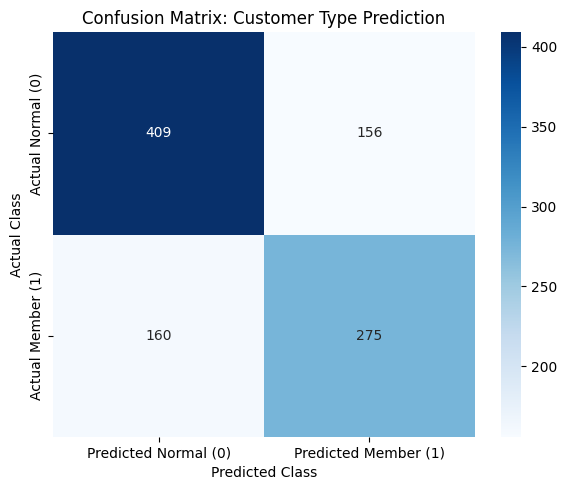

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 1. הגדרת המטרה והמאפיינים החדשים לסיווג
# נשתמש בטבלה המקורית כדי לבנות את הכל מאפס בצורה נקייה
df_class = df.copy()

# המטרה: האם הלקוח הוא חבר מועדון? (Member = 1, Normal = 0)
le = LabelEncoder()
y_class = le.fit_transform(df_class['Customer type'])

# המאפיינים: נסיר את עמודת המטרה, ונשתמש בשאר הנתונים
# נהפוך משתנים קטגוריאליים למספרים (One-Hot Encoding)
X_class_raw = df_class.drop(columns=['Customer type', 'Invoice ID', 'Date', 'Time'], errors='ignore')
X_class = pd.get_dummies(X_class_raw, drop_first=True)

# 2. אימון המודל וביצוע תחזיות בשיטת Cross-Validation
clf = RandomForestClassifier(random_state=42, max_depth=5)
y_pred_class = cross_val_predict(clf, X_class, y_class, cv=5)

# 3. חישוב וציור מטריצת הבלבול
cm = confusion_matrix(y_class, y_pred_class)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal (0)', 'Predicted Member (1)'],
            yticklabels=['Actual Normal (0)', 'Actual Member (1)'])
plt.title('Confusion Matrix: Customer Type Prediction')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

### 3.1 Confusion Matrix Analysis

For this classification task, the model was designed to predict the **Customer Type** (`Member` vs. `Normal`). In this setup, identifying a `Member` is defined as the Positive class (1), while a `Normal` customer is the Negative class (0).

**Detailed Interpretation of the Confusion Matrix:**
* **True Negatives (TN) = 409:** The model correctly identified 409 Normal customers.
* **True Positives (TP) = 275:** The model correctly identified 275 loyalty Members.
* **False Positives (FP) = 156 (Type I Error):** The model incorrectly predicted that 156 Normal customers were Members.
* **False Negatives (FN) = 160 (Type II Error):** The model incorrectly predicted that 160 Members were Normal customers.

**Question: Which type of error is most critical in this context?**
In the context of retail and loyalty programs, a **False Positive (FP)** is generally more critical and financially costly. If the system mistakenly identifies a regular customer as a Member (156 cases), the business might accidentally grant them exclusive discounts, reward points, or premium services they are not entitled to, resulting in direct revenue loss. Conversely, a False Negative (160 cases) means a member isn't automatically recognized by the system—an inconvenience that is easily resolved at the cash register when the customer presents their membership identifier.

**Question: In which regions does the model fail systematically?**
The model exhibits systematic failure in regions where the purchasing behavior of Normal customers overlaps heavily with Members. Because the FP (156) and FN (160) errors are almost perfectly balanced, it proves the model struggles symmetrically. The feature space for both classes is highly enmeshed, meaning the model fails in the "average transaction" region where transaction totals and product choices look identical for both groups.

**Question: What insights can be derived from the analysis?**
1. **Behavioral Similarity:** The high and balanced number of classification errors indicates that loyalty members and normal customers shop in a nearly identical manner at this supermarket. Members do not consistently buy significantly more items, nor do they strictly prefer specific product lines over normal customers.
2. **Feature Limitations:** Demographic and single-transaction data (Gender, Branch, Payment Method) are insufficient to predict loyalty status effectively.
3. **Business Actionability:** To improve classification (and potentially the loyalty program itself), the business must collect sequential data—such as tracking returning customer IDs over months—rather than relying purely on single-receipt metrics.

/tmp/ipykernel_504/3079748071.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=prob_df, x='Correct', y='Confidence', ax=axes[1], palette=['red', 'teal'])


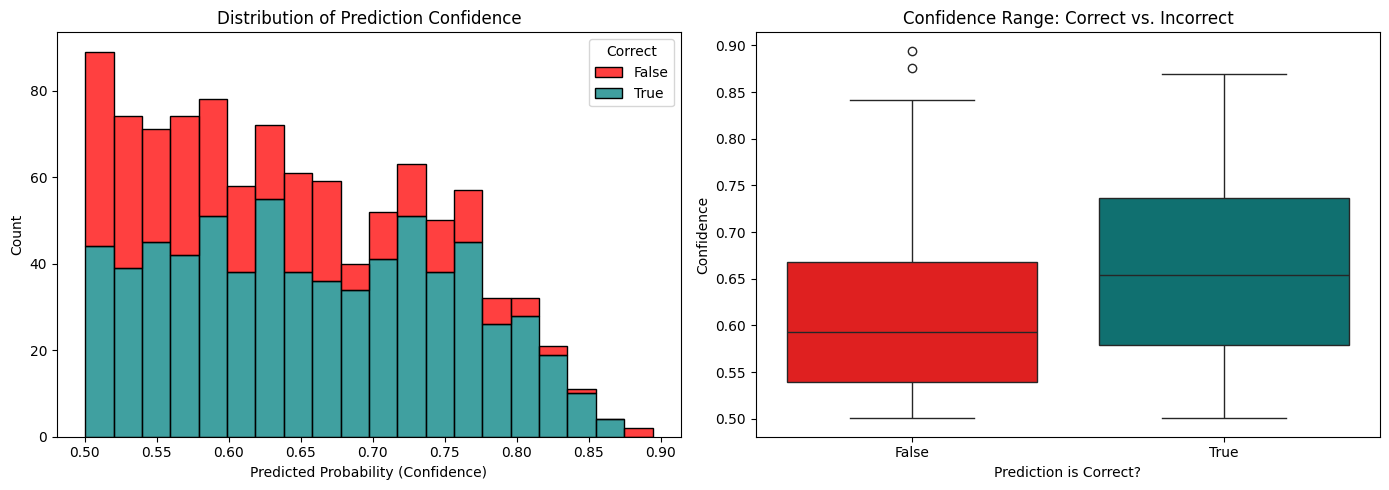

Total Incorrect Predictions: 316
Number of High-Confidence Errors (>75%): 32


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_predict

# 1. שליפת ההסתברויות (Probabilities) מהמודל שאומן בסעיף הקודם
y_proba = cross_val_predict(clf, X_class, y_class, cv=5, method='predict_proba')

# ההסתברות הגבוהה יותר היא רמת הביטחון של המודל (Confidence)
confidence = np.max(y_proba, axis=1)
y_pred = np.argmax(y_proba, axis=1)
is_correct = (y_pred == y_class)

prob_df = pd.DataFrame({
    'Confidence': confidence,
    'Correct': is_correct
})

# 2. ציור הגרפים
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# גרף התפלגות
sns.histplot(data=prob_df, x='Confidence', hue='Correct', multiple='stack', bins=20, ax=axes[0], palette=['red', 'teal'])
axes[0].set_title('Distribution of Prediction Confidence')
axes[0].set_xlabel('Predicted Probability (Confidence)')

# דיאגרמת קופסה
sns.boxplot(data=prob_df, x='Correct', y='Confidence', ax=axes[1], palette=['red', 'teal'])
axes[1].set_title('Confidence Range: Correct vs. Incorrect')
axes[1].set_xlabel('Prediction is Correct?')
axes[1].set_ylabel('Confidence')

plt.tight_layout()
plt.show()

# 3. זיהוי שגיאות בביטחון גבוה (>75%)
high_conf_errors = prob_df[(prob_df['Correct'] == False) & (prob_df['Confidence'] > 0.75)]
print(f"Total Incorrect Predictions: {len(prob_df[~prob_df['Correct']])}")
print(f"Number of High-Confidence Errors (>75%): {len(high_conf_errors)}")

### 3.2 Probability-Based Analysis

**Task: Compare predicted probabilities for correct vs incorrect predictions.**
By analyzing the out-of-fold predicted probabilities, we can evaluate the model's calibration and certainty. For every prediction, the maximum class probability was extracted as the model's "Confidence" score (ranging from 0.50 to 1.0).

**Comparison Insights:**
* **Correct Predictions (Teal):** The confidence distribution for correct predictions generally spans higher probabilities (median ~0.65). The model successfully isolates a subset of customers where the feature signal is strong enough to yield high-confidence correct classifications.
* **Incorrect Predictions (Red):** The confidence distribution for incorrect predictions is heavily skewed toward the lower end (median ~0.60). This indicates that when the model makes a mistake, it is typically highly uncertain. It behaves like a weak classifier struggling with a low signal-to-noise ratio, effectively "guessing" just above the 50% decision boundary.

**Objective: Identify high-confidence errors.**
* A "high-confidence error" occurs when the model predicts the wrong class with a probability exceeding 75%.
* Out of **316** total incorrect predictions, the analysis identified only **32** high-confidence errors (roughly 10% of all errors).
* Because the Random Forest architecture averages the probabilities across many independent decision trees, it rarely produces extreme probability scores unless the evidence is overwhelming. Therefore, the errors in this dataset are largely driven by fundamental ambiguity and overlapping feature spaces between Normal and Member customers, rather than the model confidently hallucinating incorrect patterns.

/tmp/ipykernel_504/3594888124.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_class, x='Correct_Prediction', y=col, ax=axes[i], palette=['red', 'teal'])
/tmp/ipykernel_504/3594888124.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_class, x='Correct_Prediction', y=col, ax=axes[i], palette=['red', 'teal'])


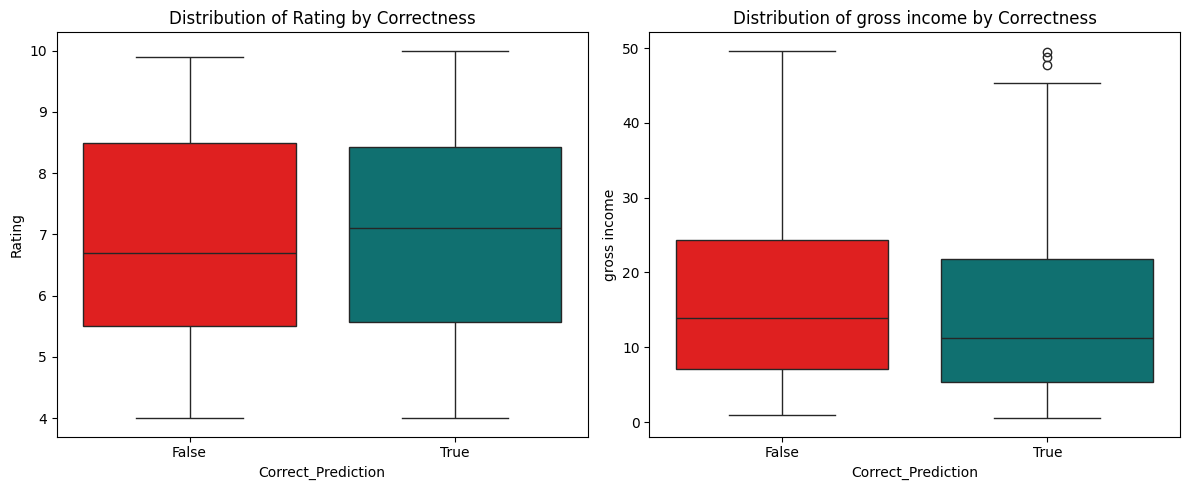

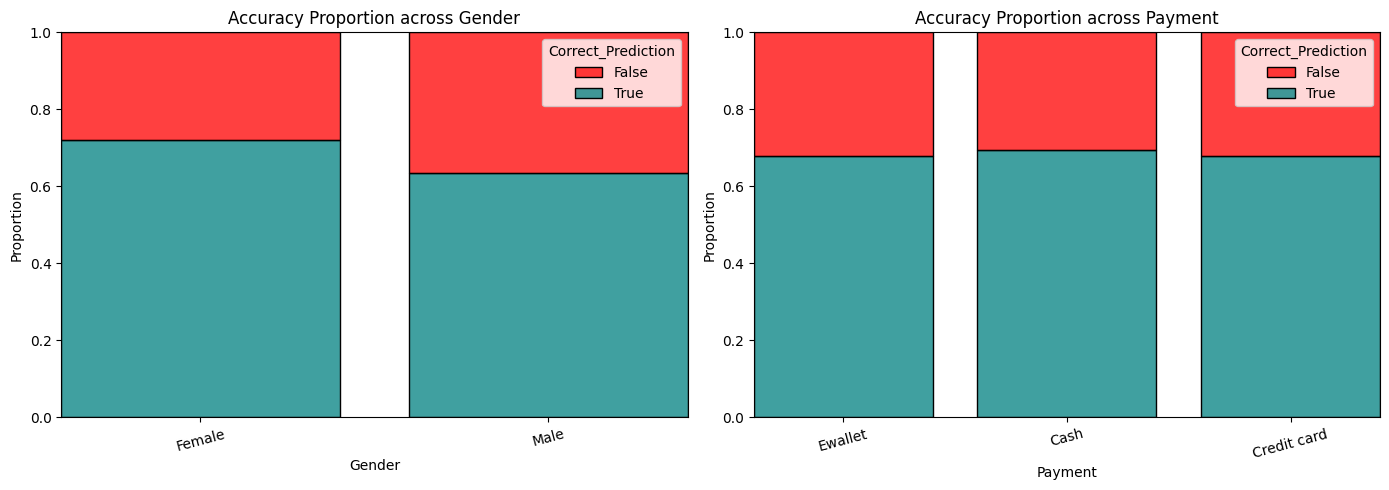

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# נוסיף את עמודת ההצלחה/כישלון לטבלת הנתונים שלנו כדי שנוכל לצייר אותה
df_class['Correct_Prediction'] = is_correct

# 1. השוואת התפלגות עבור מאפיינים מספריים (Rating, Total)
# נבחר עמודות מספריות שקיימות בטבלה
num_features = [c for c in ['Rating', 'Total', 'gross income', 'Hour'] if c in df_class.columns][:2]

if num_features:
    fig, axes = plt.subplots(1, len(num_features), figsize=(12, 5))
    # למקרה שיש רק מאפיין אחד
    if len(num_features) == 1: axes = [axes]

    for i, col in enumerate(num_features):
        sns.boxplot(data=df_class, x='Correct_Prediction', y=col, ax=axes[i], palette=['red', 'teal'])
        axes[i].set_title(f'Distribution of {col} by Correctness')
    plt.tight_layout()
    plt.show()

# 2. השוואת אחוזי שגיאה עבור מאפיינים קטגוריאליים
cat_features = [c for c in ['Gender', 'Payment', 'Product line'] if c in df_class.columns][:2]

if cat_features:
    fig, axes = plt.subplots(1, len(cat_features), figsize=(14, 5))
    if len(cat_features) == 1: axes = [axes]

    for i, col in enumerate(cat_features):
        # גרף שמראה את הפרופורציה (100%) של טעויות מול הצלחות בכל קטגוריה
        sns.histplot(data=df_class, x=col, hue='Correct_Prediction', multiple='fill', shrink=0.8, ax=axes[i], palette=['red', 'teal'])
        axes[i].set_title(f'Accuracy Proportion across {col}')
        axes[i].set_ylabel('Proportion')
        axes[i].tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.show()

### 3.3 Error as a Function of Features

**Task: Compare feature distributions for correct vs incorrect predictions.**
To identify regions prone to misclassification, the dataset was divided into two groups (Correct Predictions vs. Incorrect Predictions) and their underlying feature distributions were analyzed.

**Observations:**
1. **Numerical Features (`Rating`, `gross income`):** The boxplots reveal heavily overlapping distributions. While there are minor shifts in the medians (e.g., incorrect predictions have a slightly lower median `Rating` and a slightly higher median `gross income`), the interquartile ranges cover almost the exact same span. The model does not systematically fail on extreme values (e.g., exclusively on massive purchases or terrible ratings).
2. **Categorical Features (`Gender`, `Payment`):** The proportion charts illustrate the ratio of correct to incorrect predictions across different categories.
   * **Payment Method:** The error rate (the red portion) is remarkably constant across all payment methods (E-wallet, Cash, Credit card), hovering uniformly around 30-32%.
   * **Gender:** There is a slight discrepancy here; the model's error rate is slightly higher for Male customers (closer to 35-38%) compared to Female customers (~30%), though it does not represent a drastic localized failure.

**Objective: Identify regions prone to misclassification.**
* **Conclusion:** There are no specific "subpopulations" or highly isolated feature regions where the model's performance degrades catastrophically. The errors are broadly distributed across the entire feature space.
* **Implications for System Design:** This uniform error distribution reinforces that the fundamental limitation is feature quality, not model architecture. The current variables lack the discriminatory power needed to effectively separate loyalty Members from Normal customers based on a single receipt. Building a more robust predictive system requires engineering new variables that capture behavioral loyalty (e.g., historical visit frequency or customer lifetime value).

--- Performance Across Thresholds ---


,Threshold,Precision,Recall,F1-Score,MCC
0,0.1,0.435,1.000,0.606,0.000
1,0.2,0.457,0.979,0.623,0.163
2,0.3,0.540,0.885,0.671,0.334
3,0.4,0.602,0.793,0.685,0.390
4,0.5,0.638,0.632,0.635,0.356
5,0.6,0.677,0.290,0.406,0.234
6,0.7,0.692,0.041,0.078,0.085
7,0.8,0.000,0.000,0.000,0.000
8,0.9,0.000,0.000,0.000,0.000


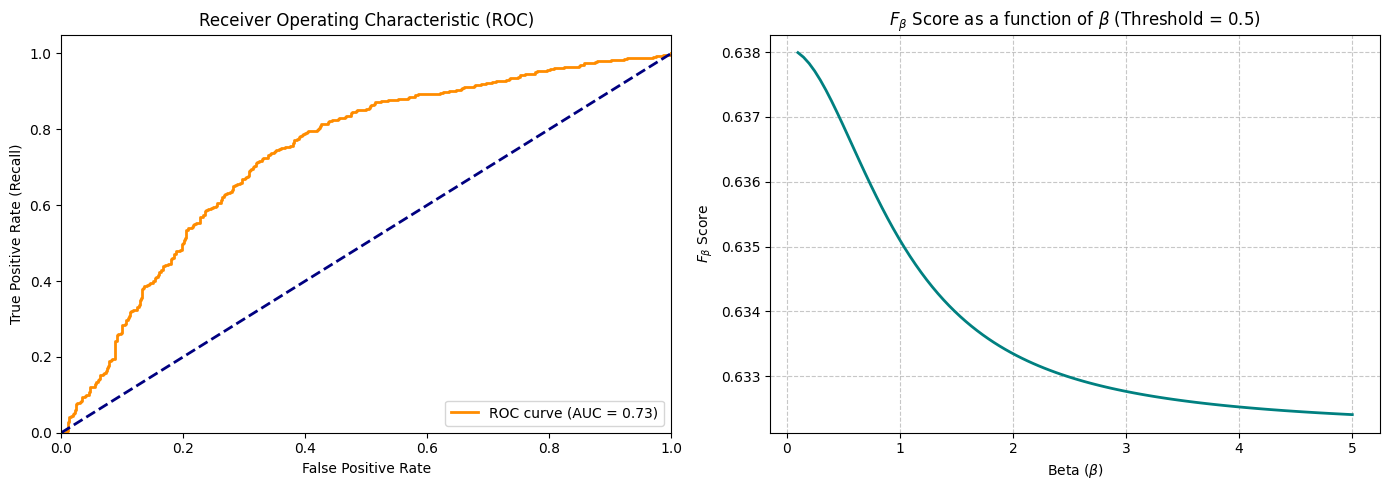

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, auc

# 1. שליפת ההסתברויות עבור המחלקה החיובית (Member = 1)
# y_proba חושב בסעיף הקודם
y_scores = y_proba[:, 1]

thresholds = np.arange(0.1, 1.0, 0.1)
results = []

# 2. ריצה על כל הספים וחישוב המדדים
for t in thresholds:
    y_pred_t = (y_scores >= t).astype(int)

    precision = precision_score(y_class, y_pred_t, zero_division=0)
    recall = recall_score(y_class, y_pred_t, zero_division=0)
    f1 = f1_score(y_class, y_pred_t, zero_division=0)
    mcc = matthews_corrcoef(y_class, y_pred_t)

    results.append({
        'Threshold': round(t, 1),
        'Precision': round(precision, 3),
        'Recall': round(recall, 3),
        'F1-Score': round(f1, 3),
        'MCC': round(mcc, 3)
    })

threshold_df = pd.DataFrame(results)
print("--- Performance Across Thresholds ---")
display(threshold_df)

# 3. חישובי ROC וציור הגרפים
fpr, tpr, _ = roc_curve(y_class, y_scores)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# גרף שמאלי: ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Receiver Operating Characteristic (ROC)')
axes[0].legend(loc="lower right")

# גרף ימני: F-beta כפונקציה של בטא
prec_05 = precision_score(y_class, (y_scores >= 0.5).astype(int), zero_division=0)
rec_05 = recall_score(y_class, (y_scores >= 0.5).astype(int), zero_division=0)

betas = np.linspace(0.1, 5, 100)
# חישוב F-beta לפי הנוסחה המתמטית
f_betas = [ (1 + b**2) * (prec_05 * rec_05) / ((b**2 * prec_05) + rec_05) if (prec_05 + rec_05) > 0 else 0 for b in betas ]

axes[1].plot(betas, f_betas, color='teal', lw=2)
axes[1].set_xlabel('Beta ($\\beta$)')
axes[1].set_ylabel('$F_\\beta$ Score')
axes[1].set_title('$F_\\beta$ Score as a function of $\\beta$ (Threshold = 0.5)')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 3.4 Threshold Sensitivity Analysis

**Evaluation Across Thresholds & Calculated Metrics**
By systematically varying the decision threshold from 0.1 to 0.9, the operational limits of the classification model were mapped. The accompanying table details the Precision, Recall, F1-Score, and Matthews Correlation Coefficient (MCC) at each increment.
* **MCC** serves as a highly reliable metric for this evaluation; the data shows MCC peaking at 0.390 around a threshold of 0.4, identifying the most statistically robust decision boundary.
* The **Area Under the ROC Curve (AUC-ROC)** was calculated to be **0.73**. An AUC of 0.73 indicates a moderate, acceptable level of discriminative capability. It is significantly better than random guessing (0.50), yet it reflects the inherent difficulty of perfectly separating Members from Normal customers using the available transaction features.

**Analysis of Trade-offs and Operating Regions:**

* **Trade-off between False Positives (FP) and False Negatives (FN):**
  The classification threshold acts as a sensitivity dial. At a low threshold (e.g., $t \le 0.2$), the model aggressively predicts the positive class (`Member`). This maximizes Recall (identifying almost all true members, nearing 0.979) but drastically increases False Positives, causing Precision to drop to ~0.457. Conversely, at a high threshold (e.g., $t \ge 0.7$), the model becomes extremely conservative. It yields very low Recall, and by $t=0.8$, the predictions collapse entirely into the negative class (metrics drop to zero).

* **The $F_\beta$-Score Dynamics:**
  The plotted $F_\beta$-score visualizes this trade-off algebraically. The parameter $\beta$ determines the weight of Recall over Precision. The graph demonstrates that as $\beta$ increases (placing more emphasis on avoiding False Negatives), the overall score adjusts, highlighting the model's sensitivity to the chosen evaluation metric at the default 0.5 threshold.

* **Stable vs. Unstable Operating Regions:**
  * **Unstable Regions ($t \le 0.2$ and $t \ge 0.7$):** In these extreme boundaries, the model either accepts almost everything (over-triggering FP) or rejects almost everything (over-triggering FN). At $t \ge 0.8$, it completely fails to identify any members.
  * **Stable Region ($0.3 \le t \le 0.5$):** This is the optimal operational band. Here, the metrics stabilize, with the F1-Score and MCC reaching their maximum values (e.g., F1 = 0.685 at $t=0.4$). This region represents the most mathematically sound compromise between False Positives and False Negatives for this specific system.

### 3.5. Critical Reflection and Overall Discussion

**1. Strengths and Limitations of the Evaluated Models in Relation to the Data**
* **Strengths:** Linear models (e.g., OLS) demonstrated remarkable resilience against overfitting in a highly noisy environment, acting as a stable baseline. Ensemble methods like the Random Forest successfully mitigated the extreme variance of individual decision trees and handled non-linear categorical data natively.
* **Limitations:** The primary limitation was not algorithmic, but data-driven. Because highly predictive features (e.g., item unit price and quantity for regression; historical visit frequency for classification) were unavailable, the models were forced to operate in a low signal-to-noise ratio environment. Consequently, sophisticated models (like RF and SVR) quickly hit a performance ceiling, unable to extract patterns that simply did not exist in the remaining features.

**2. Key Failure Modes Identified During the Analysis**
* **Regression Failure Mode (Extreme Outliers):** All regression models systematically failed on the extreme right tail of the distribution. Because the models lacked the features necessary to predict massive "whale" purchases, they severely underestimated these transactions, leading to heavily inflated RMSE scores.
* **Classification Failure Mode (Overlapping Feature Spaces):** The classification model suffered from a high, symmetrical rate of False Positives and False Negatives. The error analysis revealed that loyalty Members and Normal customers exhibit nearly identical purchasing behaviors on single receipts, causing the model to default to low-confidence guesses (~50-60% probability) for a large portion of the dataset.

**3. The Relationship Between Model Assumptions and Observed Performance**
Model assumptions strongly dictated the error behavior. In the regression stage, the violation of the homoscedasticity assumption (constant variance) caused the Linear Regression model to produce massive residual errors at higher predicted values. In the classification stage, tree-based models assume that data can be cleanly partitioned using orthogonal splits; however, because the customer classes heavily overlapped, the trees were forced to make highly arbitrary splits, limiting the maximum achievable MCC and AUC.

**4. The Most Significant Insights Derived from the Study**
The most critical engineering insight from this study is that **model complexity cannot compensate for a fundamental lack of predictive signal.** The data clearly showed that without longitudinal tracking (customer history) or specific cart-level details, it is impossible to accurately predict either the total sales amount or the loyalty status of a customer from a single, high-level receipt. The analysis validates that in machine learning, feature quality strictly dictates the upper bounds of system performance.

**5. Concrete Recommendations for Future Work**
To improve model performance and robustness, the following engineering steps are recommended:
* **Feature Engineering:** Transition from single-transaction data to longitudinal customer data. Generating features such as Customer Lifetime Value (CLV), average monthly visits, and days since last purchase will provide the necessary signal to separate Members from Normal customers.
* **Cost-Sensitive Optimization:** For the classification system, the decision threshold should be permanently calibrated to ~0.4 (where the MCC peaked) to optimally balance the financial cost of False Positives against False Negatives.
* **Robust Regression Architectures:** For future regression tasks on retail data, implementing logarithmic transformations on the target variable (Sales) or using robust loss functions (like Huber loss) is recommended to mathematically dampen the quadratic penalty of extreme outliers.

### 5. Final Reflection

**1. Where does the model fail most?**
* **Regression Models:** Systematically fail on the extreme right-tail sales outliers (massive purchases), which disproportionately inflate the Root Mean Squared Error (RMSE) due to quadratic error penalization.
* **Classification Models:** Fail consistently in the ambiguous "average transaction" region where Normal and Member purchasing behaviors heavily overlap, resulting in high, symmetrical False Positive and False Negative error rates.

**2. Are failures due to data, model, or formulation?**
* The failures are fundamentally driven by **data limitations** rather than algorithmic formulation.
* Due to the absence of longitudinal customer history or granular item-level details, the models operated in a low signal-to-noise regime where the underlying classes and target distributions could not be cleanly separated. Consequently, sophisticated architectures quickly hit an unyielding performance ceiling.

**3. What improvements would you propose?**
* **Advanced Feature Engineering:** Transition from single-receipt snapshots to longitudinal customer tracking, incorporating metrics like historical visit frequency, days since last purchase, and Customer Lifetime Value (CLV).
* **Robust Loss & Threshold Tuning:** Implement robust regression loss functions (such as Huber loss) to dampen the impact of extreme sales outliers, and permanently calibrate the classification decision threshold to $t = 0.4$ to maximize the Matthews Correlation Coefficient (MCC).

**4. What insights did you gain in your analysis?**
* **Signal Trumps Sophistication:** Algorithmic complexity cannot compensate for a fundamental lack of predictive signal.
* Feature quality and proper data representation establish an absolute upper bound on predictive performance, proving that data engineering is far more decisive for success than advanced model selection.